[150000. 198000. 246000. 294000. 342000.]


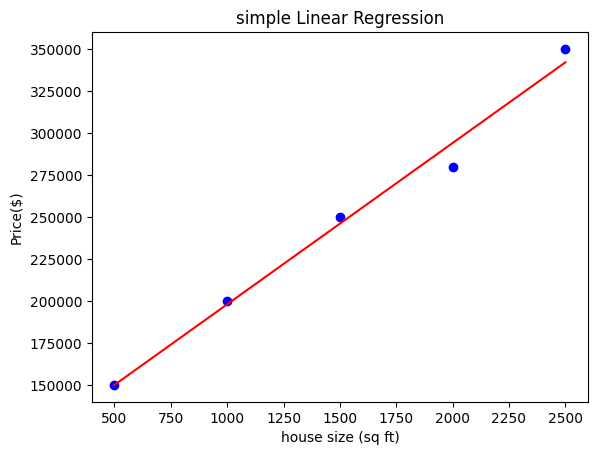

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

x=np.array([500,1000,1500,2000,2500]).reshape(-1,1)
y=np.array([150000,200000,250000,280000,350000])

model= LinearRegression()
model.fit(x,y)
y_pred=model.predict(x)
print(y_pred)
plt.scatter(x,y,color="blue")
plt.plot(x,y_pred,color="red")
plt.xlabel("house size (sq ft)")
plt.ylabel("Price($)")
plt.title("simple Linear Regression")
plt.show()


In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score

diabetes=load_diabetes(as_frame=True)
x=diabetes.data
y=diabetes.target

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model= LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)
print("MSE:",mean_squared_error(y_test,y_pred))
print("R2:",r2_score(y_test,y_pred))

[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858
  94.13865744 168.43486358  53.5047888  206.63081659 100.12925869
 130.66657085 219.53071499 250.7803234  196.3688346  218.57511815
 207.35050182  88.48340941  70.43285917 188.95914235 154.8868162
 159.36170122 188.31263363 180.39094033  47.99046561 108.97453871
 174.77897633  86.36406656 132.95761215 184.53819483 173.83220911
 190.35858492 124.4156176  119.65110656 147.95168682  59.05405241
  71.62331856 107.68284704 165.45365458 155.00975931 171.04799096
  61.45761356  71.66672581 114.96732206  51.57975523 167.57599528
 152.52291955  62.95568515 103.49741722 109.20751489 175.64118426
 154.60296242  94.41704366 210.74209145 120.2566205   77.61585399
 187.93203995 206.49337474 140.63167076 105.59678023 130.70432536
 202.18534537 171.13039501 164.91423047 124.72472569 144.81030894
 181.99635452 199.41369642 234.21436188 145.95665512  79.86703276
 157.369412

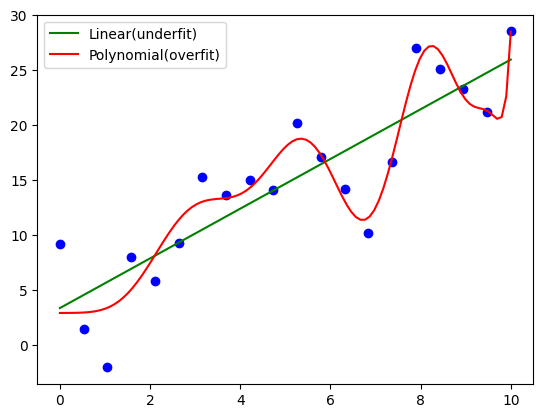

In [3]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

x=np.linspace(0,10,20).reshape(-1,1)
y=3*x.squeeze()+np.random.randn(20)*5

model_lin=LinearRegression().fit(x,y)
poly_model=make_pipeline(PolynomialFeatures(15),LinearRegression())
poly_model.fit(x,y)
x_test=np.linspace(0,10,100).reshape(-1,1)
y_lin_pred=model_lin.predict(x_test)
y_poly_pred=poly_model.predict(x_test)

plt.scatter(x,y,color="blue")
plt.plot(x_test,y_lin_pred,color="green",label="Linear(underfit)")
plt.plot(x_test,y_poly_pred,color="red",label="Polynomial(overfit)")
plt.legend()
plt.show()


In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

iris=load_iris()
x=iris.data[iris.target !=2]
y=iris.target[iris.target !=2]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

clf=LogisticRegression()
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)
print("accuracy",accuracy_score(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("Classification report:\n",classification_report(y_test,y_pred))

accuracy 1.0
confusion matrix:
 [[12  0]
 [ 0  8]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [5]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

y_true= np.array([3,-0.5,2,7])
y_pred= np.array([2.5,0.0,2,8])
mse= mean_squared_error(y_true,y_pred)
r2=r2_score(y_true,y_pred)
print("mse:",mse,"r2:",r2)

mse: 0.375 r2: 0.9486081370449679


In [6]:
from sklearn.metrics import confusion_matrix, classification_report,roc_auc_score
import numpy as np
y_true= [0,0,1,1,1,0,1,0,1,0]
y_pred = [0,0,1,0,1,0,1,1,1,0]
y_prob = [0.1,0.4,0.9,0.3,0.8,0.2,0.9,0.7,0.85,0.05]
print("confusion matrix:\n",confusion_matrix(y_true,y_pred))
print("report:\n",classification_report(y_true,y_pred))
print("roc-auc:",roc_auc_score(y_true,y_pred))

confusion matrix:
 [[4 1]
 [1 4]]
report:
               precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       0.80      0.80      0.80         5

    accuracy                           0.80        10
   macro avg       0.80      0.80      0.80        10
weighted avg       0.80      0.80      0.80        10

roc-auc: 0.8


In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report
y_true = [0]*95 + [1]*5
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit([[0]]*100, y_true)
y_pred = dummy.predict([[0]]*100)

print("accuracy:", accuracy_score(y_true,y_pred))
print(classification_report(y_true,y_pred))

accuracy: 0.95
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        95
           1       0.00      0.00      0.00         5

    accuracy                           0.95       100
   macro avg       0.47      0.50      0.49       100
weighted avg       0.90      0.95      0.93       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [8]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

iris = load_iris()
x,y = iris.data, iris.target
param_grid = {'n_estimators':[50,100],'max_depth':[2,4,6]}

grid = GridSearchCV(RandomForestClassifier(),param_grid,cv=5,scoring='accuracy')
grid.fit(x,y)
print("best params:",grid.best_params_)
print("best Scores:",grid.best_score_)


best params: {'max_depth': 4, 'n_estimators': 50}
best Scores: 0.9666666666666668


In [9]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist={'n_estimators': randint(50,200),'max_depth':randint(2,10)}
random_search = RandomizedSearchCV(RandomForestClassifier(),param_distributions=param_dist,n_iter=10,cv=5,scoring='accuracy', random_state=42)
random_search.fit(x,y)
print("best params:",random_search.best_params_)

best params: {'max_depth': 8, 'n_estimators': 156}


In [10]:
from sklearn.model_selection import cross_val_score
import numpy as np
scores = cross_val_score(RandomForestClassifier(n_estimators=100,max_depth=6),x,y,cv=5,scoring='accuracy')
print("cross-validation scores:",scores)
print("mean accuracy:",np.mean(scores))

cross-validation scores: [0.96666667 0.96666667 0.93333333 0.93333333 1.        ]
mean accuracy: 0.96
